<a href="https://colab.research.google.com/github/susanth901/CNN-BILSTM-BASED-DO-PREDICTION/blob/main/ieee_project_minor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow : 2.19.0
GPU        : []
Train timesteps : 423
Test  timesteps : 282
Sites           : 37
Features        : 11

X_train_3d : (423, 37, 11)  (T, Sites, Features)
Y_train    : (423, 37)     (T, Sites)
X_test_3d  : (282, 37, 11)
Y_test     : (282, 37)

Y (pH) range — train: [0.574, 0.963]
Y (pH) range — test : [0.574, 1.000]

Location IDs: [  2198840   2198920   2198950   2203603   2203655   2203700   2203831
   2203863   2203873   2203900   2203950   2203960   2204037   2207135
   2207160   2208450   2208493   2336120   2336152   2336240   2336300
   2336313   2336340   2336360   2336410   2336526   2336728   2337170
   2344630   2344673  21989715  21989773  21989792  21989793  22035975
  23362095 219897945]


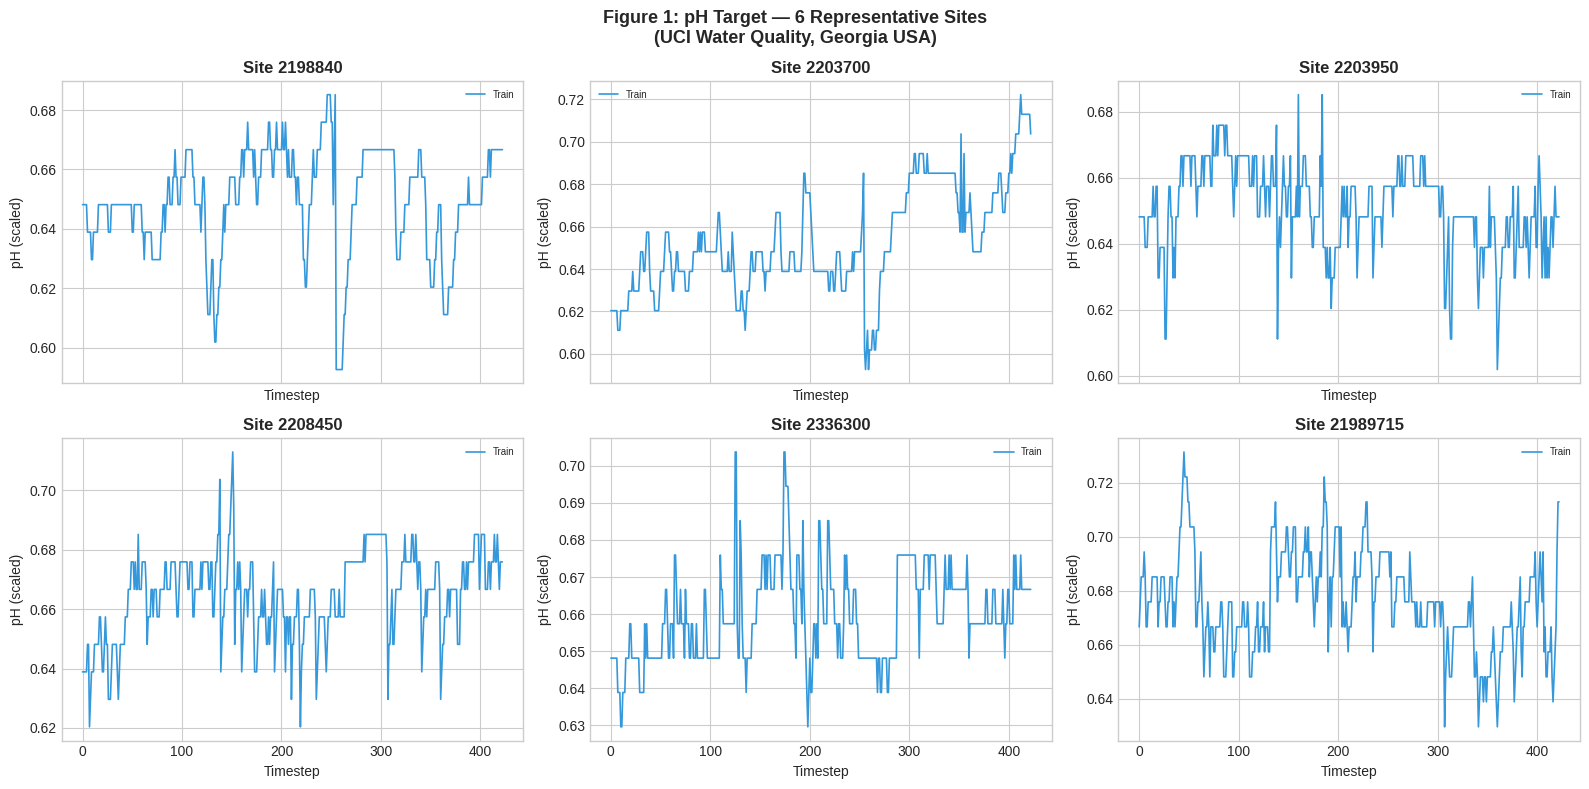


Feature statistics (scaled 0–1):
       SpCond_max  SpCond_min  SpCond_mean     DO_max    DO_mean     DO_min  \
count   15651.000   15651.000    15651.000  15651.000  15651.000  15651.000   
mean        0.065       0.889        0.029      0.043      0.568      0.859   
std         0.161       0.035        0.121      0.133      0.121      0.031   
min         0.001       0.577        0.000      0.001      0.125      0.720   
25%         0.002       0.872        0.002      0.002      0.487      0.841   
50%         0.003       0.897        0.002      0.002      0.566      0.854   
75%         0.005       0.910        0.004      0.005      0.658      0.878   
max         1.000       0.987        1.000      1.000      1.000      1.000   

        Temp_max  Temp_mean   Temp_min     pH_max     pH_min  
count  15651.000  15651.000  15651.000  15651.000  15651.000  
mean       0.605      0.578      0.557      0.537      0.553  
std        0.147      0.172      0.204      0.212      0.190  
mi

In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import scipy.io, tensorflow as tf, warnings, time
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

mat = scipy.io.loadmat('/content/water_dataset.mat')

# ── Unpack structure ─────────────────────────────────────────────
# X_tr: (1, 423) cell array → each cell is (37, 11)
# Y_tr: (37, 423) float  → pH for 37 sites × 423 timesteps

X_tr_raw = mat['X_tr'].flatten()   # 423 cells, each (37,11)
X_te_raw = mat['X_te'].flatten()   # 282 cells, each (37,11)
Y_tr     = mat['Y_tr']             # (37, 423)
Y_te     = mat['Y_te']             # (37, 282)

N_SITES    = 37
N_FEATURES = 11
T_TRAIN    = len(X_tr_raw)   # 423
T_TEST     = len(X_te_raw)   # 282

print(f"Train timesteps : {T_TRAIN}")
print(f"Test  timesteps : {T_TEST}")
print(f"Sites           : {N_SITES}")
print(f"Features        : {N_FEATURES}")

# ── Feature names (from dataset README) ──────────────────────────
FEATURE_NAMES = [
    'SpCond_max', 'SpCond_min', 'SpCond_mean',
    'DO_max',     'DO_mean',    'DO_min',
    'Temp_max',   'Temp_mean',  'Temp_min',
    'pH_max',     'pH_min'
]
# Note: features already min-max scaled to [0,1] in the .mat file

# ── Reshape to (T, Sites, Features) arrays ───────────────────────
def unpack_X(X_raw):
    """Stack cell array → (T, 37, 11)"""
    return np.stack([np.array(X_raw[t]) for t in range(len(X_raw))], axis=0)

X_train_3d = unpack_X(X_tr_raw).astype(np.float32)  # (423, 37, 11)
X_test_3d  = unpack_X(X_te_raw).astype(np.float32)  # (282, 37, 11)
Y_train    = Y_tr.T.astype(np.float32)               # (423, 37)
Y_test     = Y_te.T.astype(np.float32)               # (282, 37)

print(f"\nX_train_3d : {X_train_3d.shape}  (T, Sites, Features)")
print(f"Y_train    : {Y_train.shape}     (T, Sites)")
print(f"X_test_3d  : {X_test_3d.shape}")
print(f"Y_test     : {Y_test.shape}")
print(f"\nY (pH) range — train: [{Y_train.min():.3f}, {Y_train.max():.3f}]")
print(f"Y (pH) range — test : [{Y_test.min():.3f}, {Y_test.max():.3f}]")

# Site IDs
location_ids = mat['location_ids'].flatten()
print(f"\nLocation IDs: {location_ids}")

# ── Figure 1: pH time series for 6 representative sites ──────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.flatten()
site_picks = [0, 5, 10, 15, 20, 30]
for ax, s in zip(axes, site_picks):
    ax.plot(Y_train[:, s], color='#3498db', lw=1.2, label='Train')
    ax.set_title(f'Site {location_ids[s]}', fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('pH (scaled)')
    ax.legend(fontsize=7)

fig.suptitle('Figure 1: pH Target — 6 Representative Sites\n'
             '(UCI Water Quality, Georgia USA)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_ph_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Feature correlation across all sites/times ───────────────────
X_flat = X_train_3d.reshape(-1, N_FEATURES)
feat_df = pd.DataFrame(X_flat, columns=FEATURE_NAMES)
print(f"\nFeature statistics (scaled 0–1):")
print(feat_df.describe().round(3))
print("✅ Cell 1 complete")

In [ ]:
# ================================================================
# CELL 2: Sliding Window Preparation
# Strategy: for each site independently, build (window, 11) → pH
# Then flatten across sites to maximise training data
# Eq.4: X ∈ R^(N, W, F),  y ∈ R^(N, 1)
# ================================================================
WINDOW = 24   # 24-timestep lookback window

def make_site_windows(X_3d, Y_2d, window=24):
    """
    X_3d : (T, Sites, F)
    Y_2d : (T, Sites)
    Returns Xw (N_total, W, F), yw (N_total,)
    where N_total = Sites × (T - W)
    """
    T, S, F = X_3d.shape
    Xw, yw  = [], []
    for s in range(S):
        for t in range(T - window):
            Xw.append(X_3d[t:t+window, s, :])   # (W, F)
            yw.append(Y_2d[t+window, s])          # scalar pH
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.float32)

X_train_w, y_train_w = make_site_windows(X_train_3d, Y_train, WINDOW)
X_test_w,  y_test_w  = make_site_windows(X_test_3d,  Y_test,  WINDOW)

print(f"Windowed train : X={X_train_w.shape}, y={y_train_w.shape}")
print(f"Windowed test  : X={X_test_w.shape},  y={y_test_w.shape}")
print(f"pH train range : [{y_train_w.min():.3f}, {y_train_w.max():.3f}]")
print(f"pH test  range : [{y_test_w.min():.3f}, {y_test_w.max():.3f}]")

# 90/10 val split from training windows (chronological within each site)
val_frac  = 0.10
n_val     = int(len(X_train_w) * val_frac)
X_val_w   = X_train_w[-n_val:]
y_val_w   = y_train_w[-n_val:]
X_tr_w    = X_train_w[:-n_val]
y_tr_w    = y_train_w[:-n_val]

print(f"\nTrain  : {X_tr_w.shape}")
print(f"Val    : {X_val_w.shape}")
print(f"Test   : {X_test_w.shape}")

pd.DataFrame({
    'Split':    ['Train', 'Val', 'Test'],
    'N':        [len(X_tr_w), len(X_val_w), len(X_test_w)],
    'Window':   [WINDOW]*3,
    'Features': [N_FEATURES]*3
}).to_csv('preprocessing_summary.csv', index=False)

print("✅ Cell 2 complete")

Windowed train : X=(14763, 24, 11), y=(14763,)
Windowed test  : X=(9546, 24, 11),  y=(9546,)
pH train range : [0.574, 0.935]
pH test  range : [0.574, 1.000]

Train  : (13287, 24, 11)
Val    : (1476, 24, 11)
Test   : (9546, 24, 11)
✅ Cell 2 complete


In [ ]:
# ================================================================
# CELL 3: Baseline LSTM
# Input : (W, F) = (24, 11)
# Output: pH scalar (regression)
# ================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                      BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

F = N_FEATURES   # 11

def build_lstm(window, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window, n_features)),
        Dropout(0.2),
        LSTM(32),
        BatchNormalization(),
        Dense(16, activation='relu'),
        Dense(1)       # pH regression — no activation
    ], name='LSTM_Baseline')
    model.compile(
        optimizer=Adam(0.001),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

lstm_model = build_lstm(WINDOW, F)
lstm_model.summary()

cb_lstm = [
    EarlyStopping(patience=10, restore_best_weights=True,
                  monitor='val_rmse', mode='min'),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('lstm_ph_baseline.h5', save_best_only=True,
                    monitor='val_rmse', mode='min')
]

print("\nTraining LSTM baseline...")
hist_lstm = lstm_model.fit(
    X_tr_w, y_tr_w,
    validation_data=(X_val_w, y_val_w),
    epochs=100, batch_size=64,
    callbacks=cb_lstm, verbose=1
)

# Quick eval
p_lstm    = lstm_model.predict(X_test_w, verbose=0).flatten()
rmse_lstm = np.sqrt(np.mean((y_test_w - p_lstm)**2))
mae_lstm  = np.mean(np.abs(y_test_w - p_lstm))
r2_lstm   = 1 - np.sum((y_test_w-p_lstm)**2)/np.sum((y_test_w-y_test_w.mean())**2)
mape_lstm = np.mean(np.abs((y_test_w-p_lstm)/(y_test_w+1e-8)))*100
print(f"\nLSTM  RMSE={rmse_lstm:.4f}  MAE={mae_lstm:.4f}  "
      f"R²={r2_lstm:.4f}  MAPE={mape_lstm:.2f}%")
print("✅ Cell 3 complete")

Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,545 (127.13 KB)

 Trainable params: 32,481 (126.88 KB)

 Non-trainable params: 64 (256.00 B)

...

208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 3.4989e-04 - rmse: 0.0187 - val_loss: 2.4397e-04 - val_rmse: 0.0156 - learning_rate: 2.5000e-04
Epoch 25/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.1126e-04 - rmse: 0.0176

208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 3.2990e-04 - rmse: 0.0182 - val_loss: 2.2293e-04 - val_rmse: 0.0149 - learning_rate: 1.2500e-04
Epoch 26/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 3.2503e-04 - rmse: 0.0180 - val_loss: 2.4764e-04 - val_rmse: 0.0157 - learning_rate: 1.2500e-04
Epoch 27/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 3.2827e-04 - rmse: 0.0181 - val_loss: 2.2690e-04 - val_rmse: 0.0151 - learning_rate: 1.2500e-04
Epoch 28/100
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.0468e-04 - rmse: 0.0174

208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 3.2898e-04 - rmse: 0.0181 - val_loss: 1.7781e-04 - val_rmse: 0.0133 - learning_rate: 1.2500e-04
Epoch 29/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 3.2934e-04 - rmse: 0.0181 - val_loss: 2.6603e-04 - val_rmse: 0.0163 - learning_rate: 1.2500e-04
Epoch 30/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 3.2214e-04 - rmse: 0.0179 - val_loss: 3.0353e-04 - val_rmse: 0.0174 - learning_rate: 1.2500e-04
Epoch 31/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 3.1233e-04 - rmse: 0.0177 - val_loss: 2.1657e-04 - val_rmse: 0.0147 - learning_rate: 6.2500e-05
Epoch 32/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 3.0972e-04 - rmse: 0.0176 - val_loss: 2.0205e-04 - val_rmse: 0.0142 - learning_rate: 6.2500e-05
Epoch 33/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 3.0685e-04 - rmse: 0.0175 - val_loss: 1.7870e-04 - val_rmse: 0.0134 - learning_rate: 6.2500e-05
Epoch 34/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - l

208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 2.9493e-04 - rmse: 0.0172 - val_loss: 1.7124e-04 - val_rmse: 0.0131 - learning_rate: 3.1250e-05
Epoch 37/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 2.9355e-04 - rmse: 0.0171 - val_loss: 1.7124e-04 - val_rmse: 0.0131 - learning_rate: 3.1250e-05
Epoch 38/100
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.7772e-04 - rmse: 0.0167

208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 2.9591e-04 - rmse: 0.0172 - val_loss: 1.7006e-04 - val_rmse: 0.0130 - learning_rate: 3.1250e-05
Epoch 39/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 2.9554e-04 - rmse: 0.0172 - val_loss: 1.7692e-04 - val_rmse: 0.0133 - learning_rate: 3.1250e-05
Epoch 40/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 2.9204e-04 - rmse: 0.0171 - val_loss: 1.7814e-04 - val_rmse: 0.0133 - learning_rate: 3.1250e-05
Epoch 41/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 2.9104e-04 - rmse: 0.0171 - val_loss: 1.8680e-04 - val_rmse: 0.0137 - learning_rate: 1.5625e-05
Epoch 42/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 2.9020e-04 - rmse: 0.0170 - val_loss: 1.7586e-04 - val_rmse: 0.0133 - learning_rate: 1.5625e-05
Epoch 43/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 2.9014e-04 - rmse: 0.0170 - val_loss: 1.9798e-04 - val_rmse: 0.0141 - learning_rate: 1.5625e-05
Epoch 44/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - 

In [ ]:
# ================================================================
# CELL 4: CNN-BiLSTM (proposed model)
# CNN  (Eq.5): y_t = σ(Σ w_i·x_{t+i} + b)
#   → extracts SpCond–DO–Temp local correlations
# BiLSTM (Eq.6): h_t = [→h_t ; ←h_t]
#   → forward (rising DO) + backward (falling pH) patterns
# Loss (Eq.7): MSE = (1/N)·Σ(y−ŷ)²
# ================================================================
from tensorflow.keras.layers import (Conv1D, MaxPooling1D,
                                      Bidirectional)

def build_cnn_bilstm(window, n_features):
    model = Sequential([
        # Spatial feature extraction across sensor correlations
        Conv1D(32, kernel_size=3, activation='relu',
               padding='same', input_shape=(window, n_features)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),

        # Bidirectional temporal modelling
        Bidirectional(LSTM(64, dropout=0.3, return_sequences=True)),
        Bidirectional(LSTM(32, dropout=0.3)),

        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ], name='CNN_BiLSTM')

    model.compile(
        optimizer=Adam(0.001),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

cnn_bilstm = build_cnn_bilstm(WINDOW, F)
cnn_bilstm.summary()

cb_cb = [
    EarlyStopping(patience=15, restore_best_weights=True,
                  monitor='val_rmse', mode='min'),
    ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6),
    ModelCheckpoint('cnn_bilstm_ph.h5', save_best_only=True,
                    monitor='val_rmse', mode='min')
]

print("\nTraining CNN-BiLSTM...")
hist_cb = cnn_bilstm.fit(
    X_tr_w, y_tr_w,
    validation_data=(X_val_w, y_val_w),
    epochs=100, batch_size=64,
    callbacks=cb_cb, verbose=1
)

p_cb    = cnn_bilstm.predict(X_test_w, verbose=0).flatten()
rmse_cb = np.sqrt(np.mean((y_test_w - p_cb)**2))
mae_cb  = np.mean(np.abs(y_test_w - p_cb))
r2_cb   = 1 - np.sum((y_test_w-p_cb)**2)/np.sum((y_test_w-y_test_w.mean())**2)
mape_cb = np.mean(np.abs((y_test_w-p_cb)/(y_test_w+1e-8)))*100
print(f"\nCNN-BiLSTM  RMSE={rmse_cb:.4f}  MAE={mae_cb:.4f}  "
      f"R²={r2_cb:.4f}  MAPE={mape_cb:.2f}%")
print("✅ Cell 4 complete")

Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 24, 32)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 24, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 12, 128)        │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_21                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,057 (457.25 KB)

 Trainable params: 116,865 (456.50 KB)

 Non-trainable params: 192 (768.00 B)

...

208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 2.6559e-04 - rmse: 0.0163 - val_loss: 1.1614e-04 - val_rmse: 0.0108 - learning_rate: 2.5000e-04
Epoch 29/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 2.6183e-04 - rmse: 0.0162 - val_loss: 1.1626e-04 - val_rmse: 0.0108 - learning_rate: 2.5000e-04
Epoch 30/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 2.5624e-04 - rmse: 0.0160 - val_loss: 1.4043e-04 - val_rmse: 0.0119 - learning_rate: 2.5000e-04
Epoch 31/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 2.4725e-04 - rmse: 0.0157 - val_loss: 1.2065e-04 - val_rmse: 0.0110 - learning_rate: 1.2500e-04
Epoch 32/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.2925e-04 - rmse: 0.0151

208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 2.4759e-04 - rmse: 0.0157 - val_loss: 1.1447e-04 - val_rmse: 0.0107 - learning_rate: 1.2500e-04
Epoch 33/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 2.5084e-04 - rmse: 0.0158 - val_loss: 1.1871e-04 - val_rmse: 0.0109 - learning_rate: 1.2500e-04
Epoch 34/100
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.2666e-04 - rmse: 0.0150

208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 2.4574e-04 - rmse: 0.0157 - val_loss: 1.1335e-04 - val_rmse: 0.0106 - learning_rate: 1.2500e-04
Epoch 35/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 2.4780e-04 - rmse: 0.0157 - val_loss: 1.1737e-04 - val_rmse: 0.0108 - learning_rate: 1.2500e-04
Epoch 36/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 2.4245e-04 - rmse: 0.0156 - val_loss: 1.2134e-04 - val_rmse: 0.0110 - learning_rate: 1.2500e-04
Epoch 37/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 2.4310e-04 - rmse: 0.0156 - val_loss: 1.1469e-04 - val_rmse: 0.0107 - learning_rate: 1.2500e-04
Epoch 38/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 2.4605e-04 - rmse: 0.0157 - val_loss: 1.1455e-04 - val_rmse: 0.0107 - learning_rate: 6.2500e-05
Epoch 39/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 2.4056e-04 - rmse: 0.0155 - val_loss: 1.1452e-04 - val_rmse: 0.0107 - learning_rate: 6.2500e-05
Epoch 40/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 2.3288e-04 - rmse: 0.0153 - val_loss: 1.1202e-04 - val_rmse: 0.0106 - learning_rate: 6.2500e-05
Epoch 41/100
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.3195e-04 - rmse: 0.0152

208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 2.4512e-04 - rmse: 0.0157 - val_loss: 1.1157e-04 - val_rmse: 0.0106 - learning_rate: 6.2500e-05
Epoch 42/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 2.4019e-04 - rmse: 0.0155 - val_loss: 1.1245e-04 - val_rmse: 0.0106 - learning_rate: 6.2500e-05
Epoch 43/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 2.4045e-04 - rmse: 0.0155 - val_loss: 1.1358e-04 - val_rmse: 0.0107 - learning_rate: 6.2500e-05
Epoch 44/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 2.3502e-04 - rmse: 0.0153 - val_loss: 1.1395e-04 - val_rmse: 0.0107 - learning_rate: 6.2500e-05
Epoch 45/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 2.3808e-04 - rmse: 0.0154 - val_loss: 1.1187e-04 - val_rmse: 0.0106 - learning_rate: 3.1250e-05
Epoch 46/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 2.3053e-04 - rmse: 0.0152 - val_loss: 1.1884e-04 - val_rmse: 0.0109 - learning_rate: 3.1250e-05
Epoch 47/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step 

In [ ]:
# ================================================================
# CELL 5: Full evaluation + inference timing
# ================================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def full_eval(model, name, X, y):
    t0      = time.time()
    preds   = model.predict(X, verbose=0).flatten()
    inf_ms  = (time.time() - t0) / len(X) * 1000

    rmse   = np.sqrt(mean_squared_error(y, preds))
    mae    = mean_absolute_error(y, preds)
    r2     = r2_score(y, preds)
    mape   = np.mean(np.abs((y - preds) / (y + 1e-8))) * 100
    params = model.count_params()

    print(f"\n{'='*52}")
    print(f"  Model   : {name}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  MAE     : {mae:.4f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE    : {mape:.2f}%")
    print(f"  Latency : {inf_ms:.3f} ms/sample")
    print(f"  Params  : {params:,}")

    return dict(name=name, rmse=rmse, mae=mae, r2=r2,
                mape=mape, inf_ms=inf_ms, params=params,
                preds=preds)

res_lstm = full_eval(lstm_model, 'LSTM Baseline', X_test_w, y_test_w)
res_cb   = full_eval(cnn_bilstm, 'CNN-BiLSTM',    X_test_w, y_test_w)

imp_rmse = (res_lstm['rmse'] - res_cb['rmse']) / res_lstm['rmse'] * 100
imp_r2   = (res_cb['r2']    - res_lstm['r2'])  / max(abs(res_lstm['r2']), 1e-8) * 100
print(f"\nRMSE improvement : {imp_rmse:.1f}%")
print(f"R²   improvement : {imp_r2:.1f}%")



  Model   : LSTM Baseline
  RMSE    : 0.0165
  MAE     : 0.0105
  R²      : 0.6892
  MAPE    : 1.57%
  Latency : 0.274 ms/sample
  Params  : 32,545

  Model   : CNN-BiLSTM
  RMSE    : 0.0143
  MAE     : 0.0086
  R²      : 0.7674
  MAPE    : 1.29%
  Latency : 0.249 ms/sample
  Params  : 117,057

RMSE improvement : 13.5%
R²   improvement : 11.3%
